In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("stealthtechnologies/rock-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'rock-classification' dataset.
Path to dataset files: /kaggle/input/rock-classification
Contents of base_path (/kaggle/input):
['rock-classification']
Contents of path (/kaggle/input/rock-classification):
['Rock Data']


In [ ]:
import os

# Update path to match 'Rock Data' directory
rock_data_path = os.path.join(path, 'Rock Data')

# List subdirectories in Rock Data (usually class labels)
if os.path.exists(rock_data_path):
    print(f"Classes in dataset: {os.listdir(rock_data_path)}")
else:
    print(f"Directory not found: {rock_data_path}")

Classes in dataset: ['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train']



--- Sample Images from Dataset (/kaggle/input/rock-classification/Rock Data) ---
Found 4212 images. Displaying 6 samples:


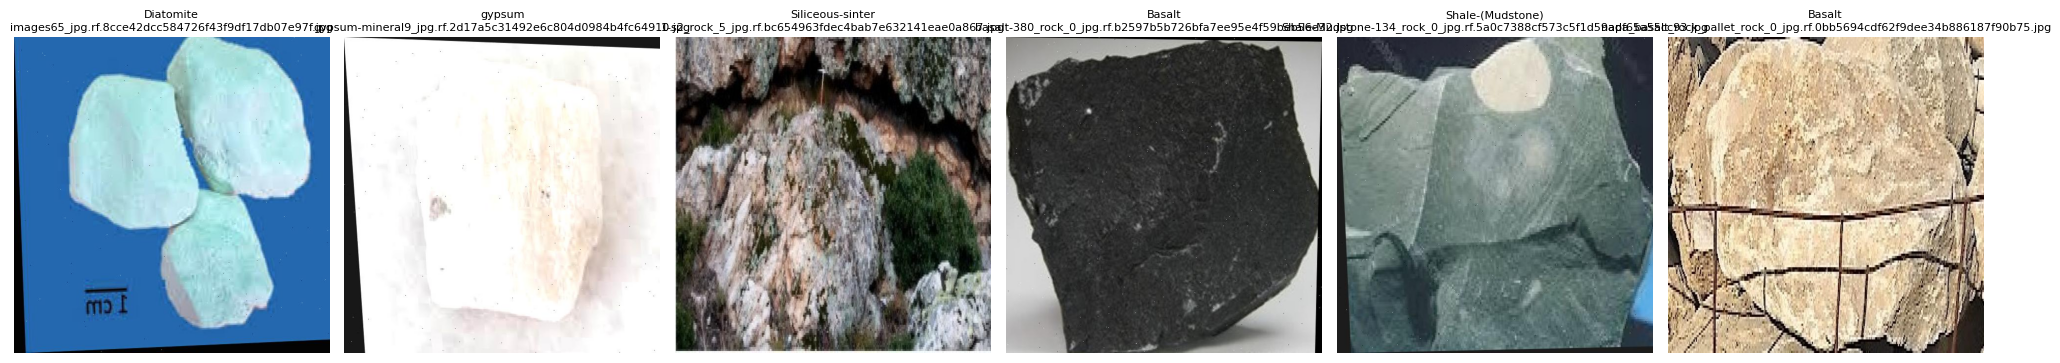

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the defined Rock Data path
rock_data_path = os.path.join(path, 'Rock Data')
print(f"\n--- Sample Images from Dataset ({rock_data_path}) ---")
display_sample_images(rock_data_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Optionally limit memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is not available. Training will proceed on CPU (which may be slow).")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
import os

# Define paths
train_dir = os.path.join(rock_data_path, 'train')
valid_dir = os.path.join(rock_data_path, 'valid')

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build VGG16 Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# FIXED: Changed 'categorical_with_cross_entropy' to 'categorical_crossentropy'
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy' if train_generator.num_classes > 2 else 'binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
print("\nStarting training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // BATCH_SIZE
)

Found 3687 images belonging to 9 classes.
Found 351 images belonging to 9 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,785 (80.64 MB)

 Trainable params: 6,425,097 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Starting training...
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 88s 617ms/step - accuracy: 0.2512 - loss: 2.0304 - val_accuracy: 0.3781 - val_loss: 1.7482
Epoch 2/10
  1/115 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.3125 - loss: 1.7917

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3125 - loss: 1.7917 - val_accuracy: 0.4000 - val_loss: 1.7297
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 514ms/step - accuracy: 0.3442 - loss: 1.7730 - val_accuracy: 0.4250 - val_loss: 1.6424
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2500 - loss: 1.7800 - val_accuracy: 0.4437 - val_loss: 1.6228
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 516ms/step - accuracy: 0.3934 - loss: 1.6636 - val_accuracy: 0.5031 - val_loss: 1.4883
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4688 - loss: 1.6031 - val_accuracy: 0.4844 - val_loss: 1.5122
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 710ms/step - accuracy: 0.4306 - loss: 1.5949 - val_accuracy: 0.4781 - val_loss: 1.4691
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3125 - loss: 1.8592 - val_accuracy: 0.4812 - val_loss: 1.4729
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 518ms/step - accuracy: 0.4462 - loss: 1.5366 - val_accurac

In [ ]:
# Summarize training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.6562
Final Validation Accuracy: 0.5063
Final Training Loss:       1.2036
Final Validation Loss:     1.4358


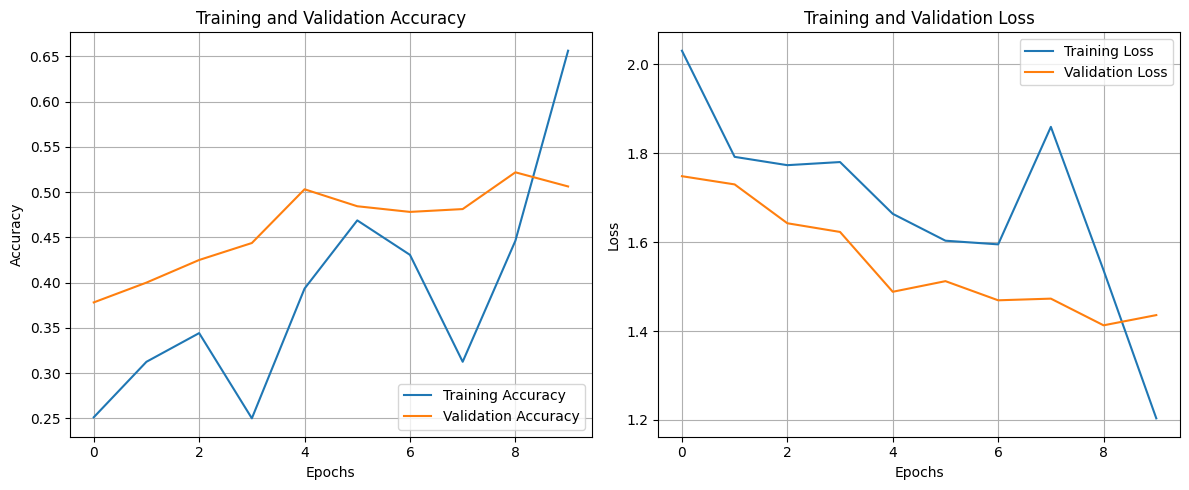

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()